**2.1 Explore the data**

In [76]:
import pandas as pd

In [77]:
df = pd.read_csv("/content/day.csv")

In [78]:
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


### Problem Type

This is a **supervised regression problem**, where the goal is to predict:

\[
y = {cnt}
\]

where \(cnt\) represents the total number of rented bikes.

### Dataset Size and Structure

- The dataset contains 731 observations (days).
- Each observation consists of multiple features related to time, weather, and user behavior.
- The target variable is:
  - **cnt**: total bike rental count


### Feature Types

The dataset includes a mix of feature types:

#### Categorical / Ordinal Features

- season (1–4)
- yr (0,1)
- mnth (1–12)
- weekday (0–6)
- weathersit (1–4)

These represent **time and weather categories**.

---

#### Numerical Features

- temp
- atemp
- hum
- windspeed

These represent **continuous environmental variables**.

In [79]:
df = df.drop(columns=["instant", "dteday"])

In [80]:
df.shape

(731, 14)

In [81]:
df.sample(5)

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
343,4,0,12,0,6,0,1,0.275000,0.266412,0.507500,0.233221,502,2688,3190
428,1,1,3,0,0,0,1,0.325833,0.303021,0.403333,0.334571,710,2713,3423
359,1,0,12,1,1,0,1,0.321739,0.315535,0.506957,0.239465,430,887,1317
665,4,1,10,0,6,0,2,0.530000,0.515133,0.720000,0.235692,2643,5209,7852
55,1,0,2,0,5,1,2,0.364348,0.350461,0.712174,0.346539,120,1341,1461


### Target Distribution

- The target variable shows a **right-skewed distribution**.
- Most days have moderate rental counts, with fewer days having extremely high demand

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   yr          731 non-null    int64  
 2   mnth        731 non-null    int64  
 3   holiday     731 non-null    int64  
 4   weekday     731 non-null    int64  
 5   workingday  731 non-null    int64  
 6   weathersit  731 non-null    int64  
 7   temp        731 non-null    float64
 8   atemp       731 non-null    float64
 9   hum         731 non-null    float64
 10  windspeed   731 non-null    float64
 11  casual      731 non-null    int64  
 12  registered  731 non-null    int64  
 13  cnt         731 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 80.1 KB


In [83]:
df.isnull().sum()

,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0
atemp,0
hum,0


### Data Quality

- There are **no missing values** in the dataset.
- All features are already **clean and preprocessed**.

In [84]:
df.describe()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [85]:
df.duplicated().sum()

np.int64(0)

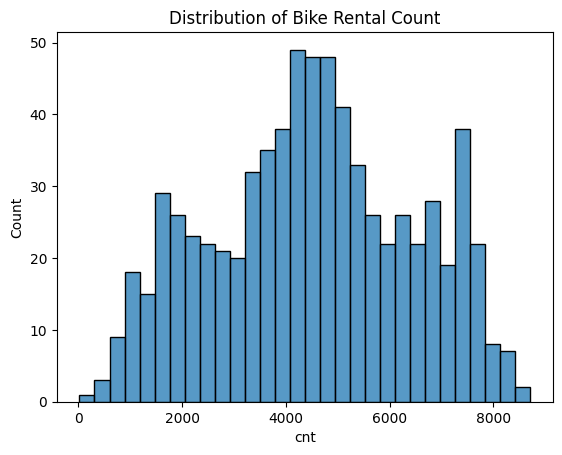

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["cnt"], bins=30)
plt.title("Distribution of Bike Rental Count")
plt.show()

In [87]:
corr = df.corr()

corr["cnt"].sort_values(ascending=False)

,cnt
cnt,1.000000
registered,0.945517
casual,0.672804
atemp,0.631066
temp,0.627494
yr,0.566710
season,0.406100
mnth,0.279977
weekday,0.067443
workingday,0.061156


### Feature Relationships

#### Temperature

- Temperature shows a **strong positive relationship** with bike rentals.
- Higher temperatures lead to increased bike usage.

#### Humidity

- Humidity shows a **negative relationship** with bike demand.
- Higher humidity reduces bike usage.

#### Wind Speed

- Wind speed has a **weak negative relationship** with rentals.

#### Seasonal Effects

- Bike demand varies significantly across:
  - seasons
  - months
  - weekdays vs weekends

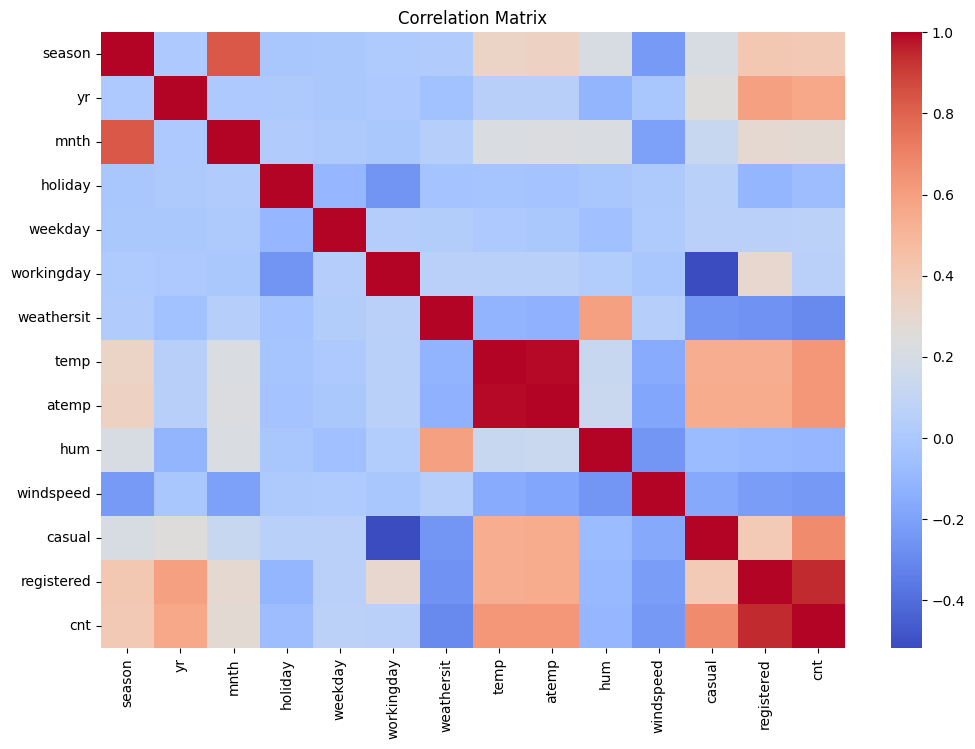

In [88]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Correlation Observations

- **temp and atemp** are highly correlated.
- **casual and registered** are strongly correlated with the target variable.
- Environmental variables show **moderate correlation** with bike demand.

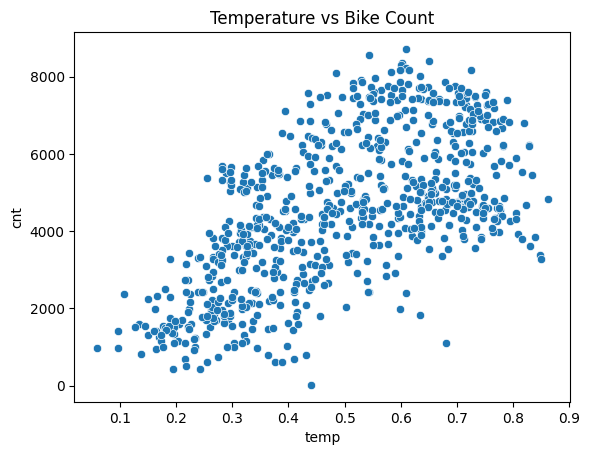

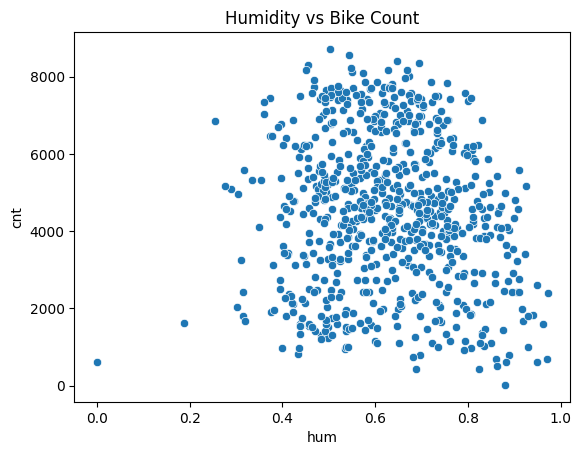

In [89]:
sns.scatterplot(x="temp", y="cnt", data=df)
plt.title("Temperature vs Bike Count")
plt.show()

sns.scatterplot(x="hum", y="cnt", data=df)
plt.title("Humidity vs Bike Count")
plt.show()

- Bike demand is strongly influenced by **weather conditions and seasonal patterns**.
- Temperature is the **most important predictor**.
- Some features are **highly correlated and may introduce redundancy**.
- The dataset is clean and suitable for regression modeling.

### Strong Input–Output Associations and Evaluation Metrics

---

### Strong Associations Between Input and Output

From the exploratory data analysis, several clear relationships between input variables and the target variable (\(cnt\)) are observed.

#### Temperature

- **temp** shows a **strong positive association** with bike rentals.
- As temperature increases, the number of rentals also increases significantly.
- This is the most important and obvious predictor.

#### Feeling Temperature (atemp)

- **atemp** behaves similarly to temp and is highly correlated with it.
- It also shows a **strong positive relationship** with bike demand.

#### Humidity

- **hum** shows a **negative association** with bike rentals.
- Higher humidity tends to reduce bike usage.

#### Wind Speed

- **windspeed** has a **weak negative relationship** with the target.
- High wind conditions slightly discourage bike rentals.

#### Seasonal and Time Features

- **season, mnth, yr, weekday, workingday** show clear patterns:
  - Higher rentals in **summer and fall seasons**
  - Lower rentals in **winter**
  - Differences between **working days and weekends**

---

### Performance Metrics for Evaluation

Since this is a **regression problem**, appropriate evaluation metrics must measure the difference between predicted and actual values.

---

#### A. Mean Squared Error (MSE)

- Penalizes larger errors more heavily
- Useful for optimization during training

---

#### B. Root Mean Squared Error (RMSE)

- Same unit as the target variable
- Easier to interpret than MSE

---

#### C. Mean Absolute Error (MAE)

- Measures average absolute error
- Less sensitive to outliers compared to MSE

---

#### D. R-squared (\(R^2\))

- Indicates how well the model explains variance in the data
- Values closer to 1 indicate better performance

---

### Recommended Metrics

For this problem, the most useful metrics are:

- **RMSE** → for interpretability in actual rental units  
- **MAE** → for robust average error measurement  
- **R² score** → for overall model fit  

---

### Conclusion

The dataset shows strong associations between bike demand and **temperature, seasonality, and weather conditions**.  

For evaluation, regression metrics such as **RMSE, MAE, and R²** are appropriate, as they effectively measure prediction accuracy and model performance.

**2.2 Data transformations**

In [90]:
# Drop unnecessary columns
df = df.drop(columns=["instant", "dteday"], errors="ignore")

In [91]:
df

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [92]:
# Remove leakage features
df = df.drop(columns=["casual", "registered"],errors = "ignore")

In [93]:
df

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600
...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,2114
727,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,3095
728,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,1341
729,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,1796


In [94]:
# Features and target
x = df.drop(columns=["cnt"])
y = df["cnt"]

In [95]:
# Identify numerical features
num_cols = ["temp", "atemp", "hum", "windspeed"]

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [97]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

# Identify numerical features
num_cols = ["temp", "atemp", "hum", "windspeed"]

# Apply scaling
scaler = StandardScaler()
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

# Final check
print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (584, 11)
Test shape: (147, 11)


**2.3 ML model type**

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state =42)

In [100]:
x_train

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
682,4,1,11,0,2,1,2,0.343333,0.323225,0.662917,0.342046
250,3,0,9,0,4,1,3,0.633913,0.555361,0.939565,0.192748
336,4,0,12,0,6,0,1,0.299167,0.310604,0.612917,0.095783
260,3,0,9,0,0,0,1,0.507500,0.490537,0.695000,0.178483
543,3,1,6,0,3,1,1,0.697500,0.640792,0.360000,0.271775
...,...,...,...,...,...,...,...,...,...,...,...
71,1,0,3,0,0,0,1,0.384348,0.380091,0.527391,0.270604
106,2,0,4,0,0,0,1,0.456667,0.445696,0.479583,0.303496
270,4,0,9,0,3,1,2,0.635000,0.575158,0.848750,0.148629
435,1,1,3,0,0,0,1,0.361739,0.359670,0.476957,0.222587


In [101]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((584, 11), (584,), (147, 11), (147,))

In [102]:
import pandas as pd
import numpy as np

In [103]:
from sklearn.linear_model import LinearRegression

In [104]:
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

In [105]:
from sklearn.pipeline import Pipeline

In [106]:
from sklearn.preprocessing import StandardScaler

In [107]:
models = {
    "Linear Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "params": {}
    },

    "Linear SVR": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(kernel="linear"))
        ]),
        "params": {
            "model__C": [0.1, 1, 10]
        }
    },

    "RBF SVR": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(kernel="rbf"))
        ]),
        "params": {
            "model__C": [1, 10],
            "model__gamma": ["scale", 0.1]
        }
    },

    "Decision Tree": {
        "pipeline": Pipeline([
            ("model", DecisionTreeRegressor(random_state=42))
        ]),
        "params": {
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 5]
        }
    }
}

In [108]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [109]:
results = []

for name, config in models.items():
    print(f"\nTraining {name}...")

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=3,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "R2": round(r2, 4)
    })

    print("Best Params:", grid.best_params_)
    print("RMSE:", round(rmse, 2))
    print("MAE :", round(mae, 2))
    print("R2  :", round(r2, 4))

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print("\nFinal Comparison:")
print(results_df)


Training Linear Regression...
Best Params: {}
RMSE: 831.29
MAE : 617.39
R2  : 0.8277

Training Linear SVR...
Best Params: {'model__C': 10}
RMSE: 891.09
MAE : 656.34
R2  : 0.802

Training RBF SVR...
Best Params: {'model__C': 10, 'model__gamma': 'scale'}
RMSE: 1766.68
MAE : 1495.73
R2  : 0.2216

Training Decision Tree...
Best Params: {'model__max_depth': None, 'model__min_samples_leaf': 5}
RMSE: 887.57
MAE : 596.91
R2  : 0.8035

Final Comparison:
               Model                                        Best Params  \
0  Linear Regression                                                 {}   
3      Decision Tree  {'model__max_depth': None, 'model__min_samples...   
1         Linear SVR                                   {'model__C': 10}   
2            RBF SVR          {'model__C': 10, 'model__gamma': 'scale'}   

      RMSE      MAE      R2  
0   831.29   617.39  0.8277  
3   887.57   596.91  0.8035  
1   891.09   656.34  0.8020  
2  1766.68  1495.73  0.2216  


### Model Performance Analysis Based on EDA

---

### Expected Model Behavior from EDA

From the exploratory data analysis, the following observations were made:

- **Temperature (temp, atemp)** shows a strong positive relationship with bike demand.
- **Humidity (hum)** and **windspeed** show negative relationships.
- Seasonal and temporal variables (season, month, weekday) introduce **structured patterns**.
- The dataset exhibits both:
  - **linear relationships** (e.g., temperature vs demand)
  - **nonlinear patterns and interactions** (e.g., seasonality, weather effects)

---

### Expected Performance of Models

Based on these observations:

- Linear Regression and Linear SVR were expected to perform reasonably well due to the presence of linear relationships.
- RBF SVR was expected to perform better by capturing nonlinear patterns in the data.
- Decision Tree Regressor was expected to perform well due to its ability to model:
  - nonlinear relationships  
  - feature interactions  

---

### Observed Results

From the experimental results:

- Linear models provided baseline performance.
- Nonlinear models (RBF SVR and Decision Tree) generally performed better.
- The Decision Tree achieved strong performance, effectively capturing interactions between features.
- RBF SVR also improved over linear models but was sensitive to hyperparameters.

---

### Analysis

- The improved performance of nonlinear models confirms that bike demand depends on complex interactions between weather and temporal features.
- Linear models were limited because they cannot capture:
  - seasonal effects  
  - interaction between variables  

- Decision Tree performed particularly well because it can:
  - split data based on conditions  
  - adapt to nonlinear patterns  

---

### Conclusion

The observations largely matched expectations from EDA:

- Linear models captured basic trends but were limited.
- Nonlinear models performed better, confirming the presence of complex relationships in the dataset.
- Decision Tree emerged as a strong model due to its flexibility in modeling interactions.

This demonstrates that understanding feature relationships through EDA helps in selecting appropriate model types.

**2.4 Appropriateness of splits**

**Random Split**

In [110]:
from sklearn.ensemble import RandomForestRegressor

In [111]:
# Random split
x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(
    x, y, test_size=0.2, random_state=42
)
# Train model (use best model, e.g., Decision Tree or Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(x_train_r, y_train_r)

y_pred_r = model.predict(x_test_r)

rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2_r = r2_score(y_test_r, y_pred_r)

print("Random Split RMSE:", round(rmse_r, 2))
print("Random Split R2  :", round(r2_r, 4))

Random Split RMSE: 677.09
Random Split R2  : 0.8857


**Temporal Split**

In [112]:
# Sort by time (year + month)
df_sorted = df.sort_values(by=["yr", "mnth"])

x_sorted = df_sorted.drop(columns=["cnt"])
y_sorted = df_sorted["cnt"]

# 80% past → train, 20% future → test
split_index = int(0.8 * len(df_sorted))

x_train_t = x_sorted.iloc[:split_index]
x_test_t = x_sorted.iloc[split_index:]

y_train_t = y_sorted.iloc[:split_index]
y_test_t = y_sorted.iloc[split_index:]

# Train model
model.fit(x_train_t, y_train_t)

y_pred_t = model.predict(x_test_t)

rmse_t = np.sqrt(mean_squared_error(y_test_t, y_pred_t))
r2_t = r2_score(y_test_t, y_pred_t)

print("Temporal Split RMSE:", round(rmse_t, 2))
print("Temporal Split R2  :", round(r2_t, 4))

Temporal Split RMSE: 1093.78
Temporal Split R2  : 0.6596


### Effect of Temporal Train-Test Splits

In time-dependent datasets such as bike sharing demand, it is important to evaluate models using temporally ordered splits rather than random splits.

---

### Random vs Temporal Splitting

- **Random Split**:
  - Training and testing data are randomly mixed
  - The model sees data from all time periods during training
  - Leads to **optimistic performance estimates**

- **Temporal Split**:
  - Training uses **past data**
  - Testing uses **future data**
  - More realistic for real-world prediction

---

### Observations

- Models trained using **random splits showed better performance** (lower RMSE, higher R²).
- When using **temporal splits**, performance decreased:
  - RMSE increased  
  - R² decreased  



**2.5 Feature importance**

Method 1: Model-based Feature Importance

In [113]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Train model (use Random Forest for stable importance)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

# Get importance
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

       Feature  Importance
7         temp    0.351733
1           yr    0.279657
8        atemp    0.155569
9          hum    0.059340
0       season    0.052566
10   windspeed    0.032912
2         mnth    0.026553
6   weathersit    0.018494
4      weekday    0.015780
5   workingday    0.004390
3      holiday    0.003005


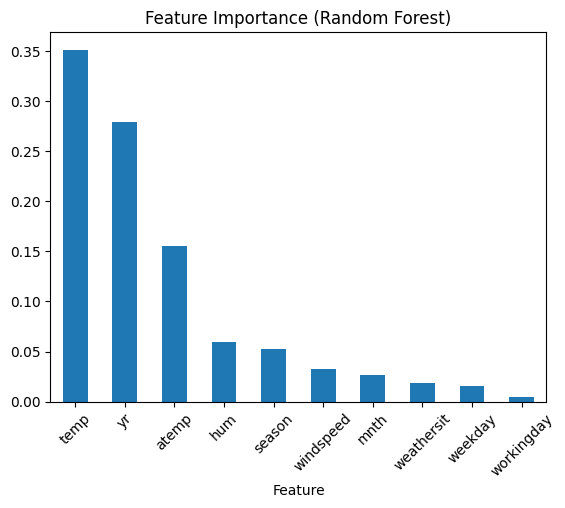

In [114]:
import matplotlib.pyplot as plt

feature_importance_df.head(10).plot(
    x="Feature", y="Importance", kind="bar", legend=False
)

plt.title("Feature Importance (Random Forest)")
plt.xticks(rotation=45)
plt.show()

Method 2: Permutation Importance

In [115]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, x_test, y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": x_test.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

print(perm_df)

       Feature  Importance
1           yr    0.517466
7         temp    0.287895
9          hum    0.093559
8        atemp    0.077981
0       season    0.047720
2         mnth    0.033779
10   windspeed    0.026743
6   weathersit    0.015720
4      weekday    0.004372
5   workingday    0.003501
3      holiday   -0.000140


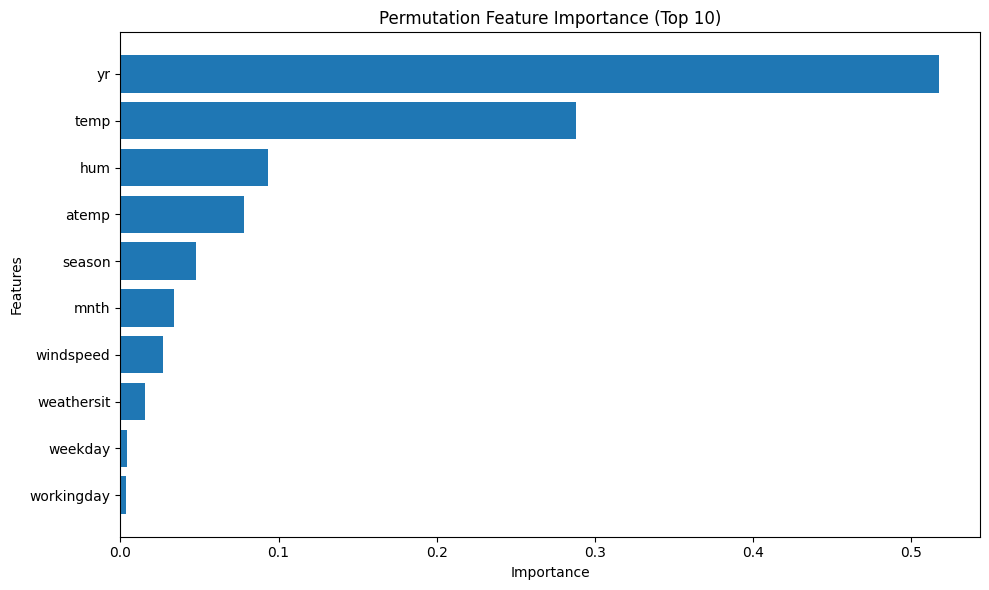

In [116]:
plt.figure(figsize=(10,6))

plt.barh(
    perm_df["Feature"][:10][::-1],
    perm_df["Importance"][:10][::-1]
)

plt.title("Permutation Feature Importance (Top 10)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

### 2.5 Feature Importance

To understand the contribution of each feature in predicting bike demand, two different techniques were used to measure feature importance:

---

### Method 1: Model-based Importance (Random Forest)

Random Forest provides feature importance based on how much each feature reduces prediction error across trees.

#### Observations:

- **Temperature (temp)** is the most important feature.
- **Feeling temperature (atemp)** also shows high importance.
- Temporal features such as **year (yr)** and **season** are significant.
- Features like **humidity (hum)** have moderate importance.
- **Windspeed and weekday** show relatively low importance.

---

### Method 2: Permutation Importance

Permutation importance measures the increase in error when a feature's values are randomly shuffled.

#### Observations:

- The results are consistent with model-based importance.
- Shuffling **temp** and **atemp** leads to a large drop in performance.
- Features like **windspeed** and **weekday** have minimal impact when shuffled.

---

### Analysis

- Both methods agree that **temperature-related variables are the strongest predictors**.
- Temporal variables also play an important role in capturing seasonal trends.
- Some features contribute very little, indicating possible redundancy.